# MarketMinds — Phase 3: Baseline Forecasting Models

First pass at the ML forecasting layer: linear regression and ARIMA, on a single asset (SENSEX / `^BSESN`), predicting the next-5-trading-day return. `^NSEI` (NIFTY 50) was tried first but its yfinance data only starts 2007-09-17, leaving no usable history before the 2008 crisis window -- `^BSESN` has full history back to 2000, like the individual stocks. Once these are working correctly here, the same approach scales to the rest of the basket.

Design, matching what was asked:
- **Target**: 5-trading-day-forward log return, `log(Close[t+5]) - log(Close[t])`.
- **No lookahead, walk-forward**: both models are refit at every single prediction day using only data strictly before that day (an expanding window) — not one static fit reused across an entire test period. Refitting a linear regression or updating an ARIMA model's state is cheap enough that there's no real efficiency cost to doing this properly.
- **Three separate evaluations**, each with train data strictly before the test window (no lookahead across windows either):
  - `normal`: train up to 2016, test on 2017 (a calm year)
  - `2008_financial_crisis`: train up to 2007, test on Jan 2008 - Mar 2009
  - `covid_crash`: train up to 2019, test on Feb 20 - Apr 30 2020
- **Metrics per window**: MAE, RMSE (both in % return terms), and directional accuracy (did the model get the sign of the move right).
- **Saved artifacts**: one `.pkl` + one `.json` metadata file per (model, window) pair in `models/`.

**Note on execution**: same as before — you run every cell, I don't execute anything. Paste back any errors.

## Setup

In [1]:
import json
import pickle
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

PROJECT_ROOT = Path('..').resolve()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

master = pq.read_table(PROCESSED_DIR / 'marketminds_master.parquet').to_pandas()
print('Master shape:', master.shape)

Master shape: (134646, 18)


## 1. Build the feature/target table for SENSEX

Features are the technical indicators already computed in Phase 1 (`daily_return`, `ma_20`, `ma_50`, `ma_200`, `rsi_14`, `macd`, `macd_signal`, `volatility_20d`) — all inherently backward-looking (rolling/EWM windows), so using them as of day t never leaks future information. The target, `target_log_return_5d`, deliberately uses `Close.shift(-5)` since that's the label we're trying to predict, not a feature — it never gets used as model input.

In [2]:
ASSET_TICKER = '^BSESN'
FEATURE_COLS = ['daily_return', 'ma_20', 'ma_50', 'ma_200', 'rsi_14', 'macd', 'macd_signal', 'volatility_20d']
TARGET_COL = 'target_log_return_5d'
HORIZON = 5

def build_feature_target_table(df):
    df = df.sort_values('date').set_index('date').copy()
    df[TARGET_COL] = np.log(df['Close'].shift(-HORIZON)) - np.log(df['Close'])
    return df[FEATURE_COLS + [TARGET_COL, 'Close']].dropna()

asset_df = master[master['ticker'] == ASSET_TICKER]
feature_table = build_feature_target_table(asset_df)

print('Raw data starts:', asset_df['date'].min())
print('Feature table shape:', feature_table.shape)
print('Feature table date range:', feature_table.index.min(), '->', feature_table.index.max())
feature_table.head()

Raw data starts: 2000-01-03 00:00:00
Feature table shape: (6738, 10)
Feature table date range: 2000-10-06 00:00:00 -> 2026-08-04 00:00:00


,daily_return,ma_20,ma_50,ma_200,rsi_14,macd,macd_signal,volatility_20d,target_log_return_5d,Close
date,,,,,,,,,,
2000-10-06,-0.005789,4291.142480,4343.679385,4811.655635,38.576134,-99.689199,-87.307021,0.021356,-0.090337,4092.419922
2000-10-09,-0.008882,4259.115979,4339.203589,4805.060436,36.874462,-101.214676,-90.088552,0.021160,-0.084163,4056.070068
2000-10-10,-0.027315,4218.198486,4333.035391,4797.331787,32.210665,-110.094359,-94.089714,0.020993,-0.073749,3945.280029
2000-10-11,-0.027570,4174.897986,4324.547993,4789.729337,28.411399,-124.473549,-100.166481,0.021383,-0.065400,3836.510010
2000-10-12,0.002885,4133.680994,4317.346997,4781.859589,29.325073,-133.437713,-106.820727,0.021564,-0.038347,3847.580078


## 2. Define train/test windows

Each window's train data ends strictly before its own test period starts. The `2008_financial_crisis` and `covid_crash` windows match the event tags from Phase 1; `normal` is a calm year (2017) used as the baseline-behavior comparison point.

In [3]:
WINDOWS = {
    'normal': {'train_end': '2016-12-31', 'test_start': '2017-01-01', 'test_end': '2017-12-31'},
    '2008_financial_crisis': {'train_end': '2007-12-31', 'test_start': '2008-01-01', 'test_end': '2009-03-31'},
    'covid_crash': {'train_end': '2019-12-31', 'test_start': '2020-02-20', 'test_end': '2020-04-30'},
}

for name, cfg in WINDOWS.items():
    train_rows = len(feature_table.loc[:cfg['train_end']])
    test_rows = len(feature_table.loc[cfg['test_start']:cfg['test_end']])
    print(name, '-> train rows:', train_rows, ', test rows:', test_rows)

normal -> train rows: 4236 , test rows: 260
2008_financial_crisis -> train rows: 1887 , test rows: 326
covid_crash -> train rows: 5018 , test rows: 51


## 3. Linear Regression baseline (walk-forward)

For every single day in a test window, the model is refit from scratch on all data strictly before that day, then used to predict just that one day's 5-day-forward return. An OLS fit on a few thousand rows x 8 columns is fast, so refitting a few hundred times per window costs seconds, not minutes -- there's no reason to fall back to one static fit for the whole window when a properly walk-forward version is this cheap.

In [4]:
def train_eval_linreg(cfg):
    test_dates = feature_table.loc[cfg['test_start']:cfg['test_end']].index
    preds = {}
    last_model = None
    for date in test_dates:
        train_slice = feature_table[feature_table.index < date]
        last_model = LinearRegression().fit(train_slice[FEATURE_COLS], train_slice[TARGET_COL])
        preds[date] = last_model.predict(feature_table.loc[[date], FEATURE_COLS])[0]
    predicted = pd.Series(preds)
    actual = feature_table.loc[predicted.index, TARGET_COL]
    return last_model, predicted, actual

linreg_models, linreg_preds, linreg_actuals = {}, {}, {}
for name, cfg in WINDOWS.items():
    print('Running walk-forward linear regression for', name, '...')
    model, predicted, actual = train_eval_linreg(cfg)
    linreg_models[name] = model
    linreg_preds[name] = predicted
    linreg_actuals[name] = actual
print('Done.')

Running walk-forward linear regression for normal ...
Running walk-forward linear regression for 2008_financial_crisis ...
Running walk-forward linear regression for covid_crash ...
Done.


## 4. ARIMA baseline (walk-forward)

A univariate model on SENSEX's own daily log-return series (no engineered features) -- `ARIMA(5, 0, 0)`, a fixed, simple, explainable order rather than a searched one, consistent with this being an explicit baseline rather than a tuned model. For each test day, the model first absorbs that day's actual return via `.append(..., refit=False)` (cheap -- it updates the model's state without re-estimating parameters), then forecasts 5 steps ahead and sums them to get the predicted 5-day return. This means each prediction only ever uses data up to and including its own day, matching the linear regression's walk-forward design.

In [5]:
ARIMA_ORDER = (5, 0, 0)
full_log_returns = np.log(feature_table['Close']).diff().dropna()

def train_eval_arima(cfg, order=ARIMA_ORDER, horizon=HORIZON):
    train_log_returns = full_log_returns.loc[:cfg['train_end']]
    test_dates = feature_table.loc[cfg['test_start']:cfg['test_end']].index

    fitted = ARIMA(train_log_returns, order=order).fit()

    preds = {}
    for date in test_dates:
        if date in full_log_returns.index:
            fitted = fitted.append([full_log_returns.loc[date]], refit=False)
        forecast = fitted.get_forecast(steps=horizon)
        preds[date] = forecast.predicted_mean.sum()

    predicted = pd.Series(preds)
    actual = feature_table.loc[predicted.index, TARGET_COL]
    return fitted, predicted, actual

arima_models, arima_preds, arima_actuals = {}, {}, {}
for name, cfg in WINDOWS.items():
    print('Running walk-forward ARIMA for', name, '...')
    model, predicted, actual = train_eval_arima(cfg)
    arima_models[name] = model
    arima_preds[name] = predicted
    arima_actuals[name] = actual
print('Done.')

Running walk-forward ARIMA for normal ...
Running walk-forward ARIMA for 2008_financial_crisis ...
Running walk-forward ARIMA for covid_crash ...
Done.


## 5. Evaluation metrics per window

MAE and RMSE in percentage-return terms (easier to read than log-return units), plus directional accuracy -- the share of days where the model at least got the sign of the move right, which is often more intuitive than an error magnitude for a financial-literacy audience.

In [6]:
def compute_eval_metrics(actual_log_return, predicted_log_return):
    actual_pct = (np.exp(actual_log_return) - 1) * 100
    predicted_pct = (np.exp(predicted_log_return) - 1) * 100
    errors = predicted_pct - actual_pct
    mae = errors.abs().mean()
    rmse = np.sqrt((errors ** 2).mean())
    directional_accuracy = (np.sign(predicted_pct) == np.sign(actual_pct)).mean() * 100
    return {
        'mae_pct': round(float(mae), 3),
        'rmse_pct': round(float(rmse), 3),
        'directional_accuracy_pct': round(float(directional_accuracy), 1),
        'n_predictions': int(len(actual_pct)),
    }

metrics_lookup = {}
results = []
for name in WINDOWS:
    lr_metrics = compute_eval_metrics(linreg_actuals[name], linreg_preds[name])
    ar_metrics = compute_eval_metrics(arima_actuals[name], arima_preds[name])
    metrics_lookup[('linear_regression', name)] = lr_metrics
    metrics_lookup[('arima', name)] = ar_metrics
    results.append({'window': name, 'model': 'linear_regression', **lr_metrics})
    results.append({'window': name, 'model': 'arima', **ar_metrics})

results_df = pd.DataFrame(results)
results_df

,window,model,mae_pct,rmse_pct,directional_accuracy_pct,n_predictions
0,normal,linear_regression,1.129,1.383,49.2,260
1,normal,arima,1.054,1.303,66.9,260
2,2008_financial_crisis,linear_regression,4.978,6.351,46.6,326
3,2008_financial_crisis,arima,4.958,6.336,44.8,326
4,covid_crash,linear_regression,6.324,7.935,45.1,51
5,covid_crash,arima,6.293,7.898,31.4,51


## 6. Visualize predicted vs actual per window

The gap between the predicted and actual lines is itself the evidence: it should stay small during `normal`, and widen noticeably during the two crisis windows if the honest-evaluation story holds up.

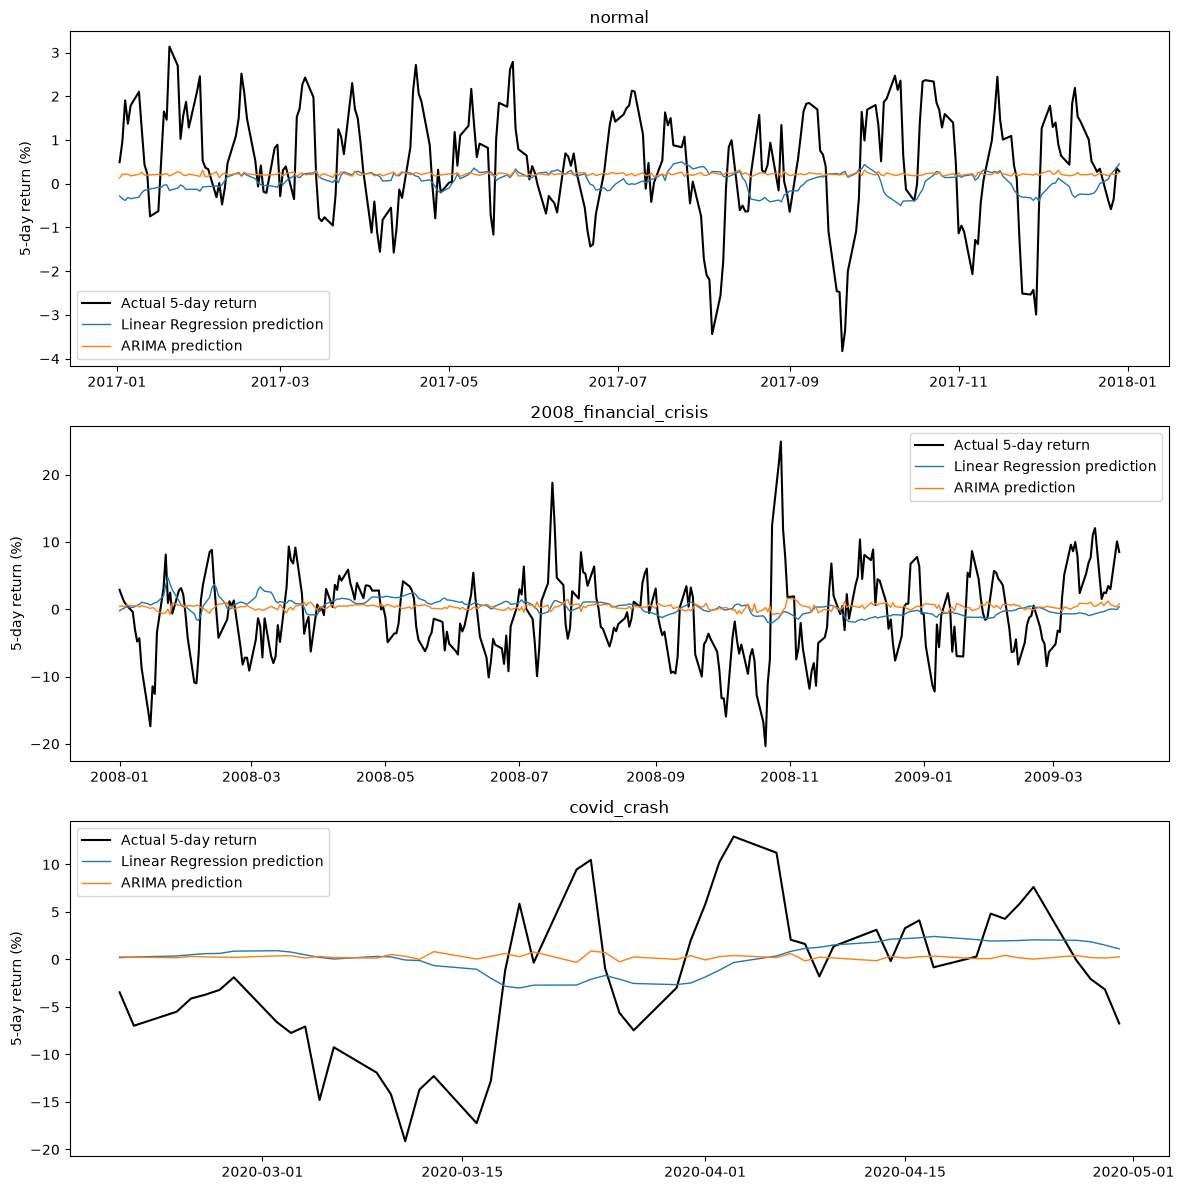

In [7]:
fig, axes = plt.subplots(len(WINDOWS), 1, figsize=(12, 4 * len(WINDOWS)))
for ax, name in zip(axes, WINDOWS):
    actual_pct = (np.exp(linreg_actuals[name]) - 1) * 100
    linreg_pct = (np.exp(linreg_preds[name]) - 1) * 100
    arima_pct = (np.exp(arima_preds[name]) - 1) * 100

    ax.plot(actual_pct.index, actual_pct, label='Actual 5-day return', color='black', linewidth=1.5)
    ax.plot(linreg_pct.index, linreg_pct, label='Linear Regression prediction', linewidth=1)
    ax.plot(arima_pct.index, arima_pct, label='ARIMA prediction', linewidth=1)
    ax.set_title(name)
    ax.set_ylabel('5-day return (%)')
    ax.legend()

plt.tight_layout()
plt.show()

## 7. Save trained models + metadata

One `.pkl` per (model, window) pair -- the walk-forward loop's *last* fitted model, i.e. the one trained on the most data for that window -- plus a matching `.json` with asset, model type, window, train/test dates, the metrics from Step 5, and when it was trained. Models are never trained inside the app itself; this is the offline training step the app will just load from.

In [8]:
def safe_asset_name(ticker):
    return ticker.replace('^', 'IDX_')

asset_name = safe_asset_name(ASSET_TICKER)

def save_model(model_obj, model_type, window_name, cfg):
    base = model_type + '_' + asset_name + '_' + window_name
    model_path = MODELS_DIR / (base + '.pkl')
    meta_path = MODELS_DIR / (base + '.json')

    with open(model_path, 'wb') as f:
        pickle.dump(model_obj, f)

    metadata = {
        'asset': ASSET_TICKER,
        'model_type': model_type,
        'window': window_name,
        'train_end': cfg['train_end'],
        'test_start': cfg['test_start'],
        'test_end': cfg['test_end'],
        'metrics': metrics_lookup[(model_type, window_name)],
        'date_trained': datetime.now().isoformat(),
    }
    with open(meta_path, 'w') as f:
        json.dump(metadata, f, indent=2)

    print('Saved', model_path.name, 'and', meta_path.name)

for name, cfg in WINDOWS.items():
    save_model(linreg_models[name], 'linear_regression', name, cfg)
    save_model(arima_models[name], 'arima', name, cfg)

Saved linear_regression_IDX_BSESN_normal.pkl and linear_regression_IDX_BSESN_normal.json
Saved arima_IDX_BSESN_normal.pkl and arima_IDX_BSESN_normal.json
Saved linear_regression_IDX_BSESN_2008_financial_crisis.pkl and linear_regression_IDX_BSESN_2008_financial_crisis.json
Saved arima_IDX_BSESN_2008_financial_crisis.pkl and arima_IDX_BSESN_2008_financial_crisis.json
Saved linear_regression_IDX_BSESN_covid_crash.pkl and linear_regression_IDX_BSESN_covid_crash.json
Saved arima_IDX_BSESN_covid_crash.pkl and arima_IDX_BSESN_covid_crash.json


## Summary

What this notebook produced:
- `results_df` (Step 5) -- MAE / RMSE / directional accuracy for both models across `normal`, `2008_financial_crisis`, and `covid_crash`
- The Step 6 chart -- predicted vs actual 5-day return, visually showing where each model's forecasts diverge from reality
- 6 saved model files in `models/` (linear regression + ARIMA, x 3 windows), each with a matching `.json` metadata file

What to look for in the results: if `normal`'s errors are meaningfully smaller than `2008_financial_crisis`'s and `covid_crash`'s, and directional accuracy drops toward (or below) 50% in the crisis windows, that's the concrete evidence the proposal is after -- forecasting degrades under regime shifts, which is the actual argument for diversification over trying to predict crashes.

Next: scale this same approach (same functions, different `ASSET_TICKER` and a loop over the basket) to the rest of the stocks, then move on to tree-based models (Random Forest / XGBoost) and eventually the LSTM, per the proposal's model roadmap.